# RQ4_refined


              Feature  Importance
2           longitude    0.078560
3                hour    0.070296
0         accident_id    0.066105
1            latitude    0.048315
11         risk_score    0.047772
7         temperature    0.042861
9          casualties    0.041700
8   vehicles_involved    0.030588
67        weather_fog    0.027931
5               lanes    0.027379


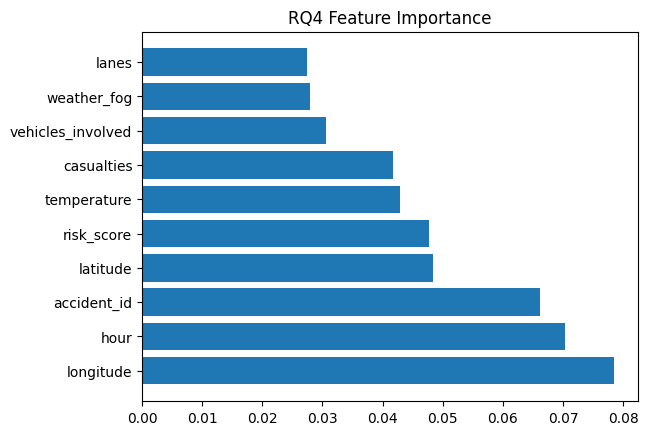

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

df = pd.read_csv('/kaggle/input/datasets/sehaj1104/indian-road-accident-dataset-20222025/indian_roads_dataset.csv')

df = df.dropna()

X = df.drop('accident_severity', axis=1)
y = df['accident_severity']

X = pd.get_dummies(X)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False).head(10)

imp
imp.to_csv("RQ4_table.csv", index=False)

plt.figure()
plt.barh(imp["Feature"], imp["Importance"])
plt.title("RQ4 Feature Importance")
plt.savefig("RQ4_figure.pdf")
print(imp)
